In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
from datetime import datetime
import os
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
os.chdir('/home/borisvdm/Documents/PhD/thesis_Mirte/Wang2021')

In [3]:
# 0: config (later we will outsource this part to yaml, for now we will continue selecting all variables here)
sc._settings.ScanpyConfig.n_jobs = 6

# 1: Variables for Data loading and set-up
sample               = 'C3L-03968'
working_dir          = '/home/borisvdm/Documents/PhD/thesis_Mirte/Wang2021/data/single_cell/'
result_folder        = working_dir + sample + '/'
result_file_name     = result_folder+sample#.h5ad'
count_file_format    = 'mtx'              # either 'hd5' or mtx file
count_file_folder    = '/home/borisvdm/Documents/PhD/thesis_Mirte/Wang2021/data/single_cell/'+sample+'/raw_feature_bc_matrix'
count_file_name      = 'matrix.mtx.gz' # t200_raw_feature_bc_matrix.h5 t162_raw_feature_bc_matrix.h5
count_file_cache     = True
cell_annotation_file = '/home/borisvdm/Documents/PhD/thesis_Mirte/Wang2021/data/Wang2021_marker_genes_flat.tsv'
cellcycle_genes_file = '/home/borisvdm/Documents/PhD/thesis_Mirte/Wang2021/data/cell_cycle_markers_regev_lab.txt'
var_names            = 'gene_symbols'     # either gene symbols or gene_ids
unique_var_names     = True  # if variable names are not unique, make them unique (can lead to probelms if marker genes are affected)
remove_existing_log  = True  # if True start a new log file and remove the old. If false, log file will be expanded

# 2: Quality control and Diagnostics
plot_high_expression_gene_nr = 20            # Number of highly expressed genes to be plotted
filter_min_genes             = 200           # Minimum number of genes that need to be expressed in a cell                  possible debris with too few genes expressed (< 200)
filter_max_genes             = 10000         # Maximum number of genes that need to be expressed in a cell                  possible more than one cell with too many genes expressed (> 10,000
filter_min_counts_per_cell   = 1000          # Filter out cells that have a to few counts per cell                         too few total transcript counts (< 300); or UMIs
filter_min_cells             = 3             # Minimum number of cells that need to contain a gene
filter_n_genes_by_counts     = 10000         # Filter out cells that have a higher total gene count                          
filter_pct_counts_mt         = 10            # Filter out cells with a higher percentage of mitochondrial genes             mitochondrial gene expression over the total transcript counts (> 10%)
filter_total_counts          = 10000         # Filter out cells that have a higher total count per cell                     and too many UMIs (> 10,000)

# 3: Normalize and scale
perform_scaling           = True             # If True, scale the data matrix
scaling_target_sum        = 1e4              # Sum to which each cells library size is scaled
perform_log_normalization = True             # Apply natural base logarithm to the data matrix

# 4: DE analysis and filtering
use_flavor_hvf_settings = True               # If true, use DE analysis and filtering settings to that of a specific protocol (e.g. Seurat)
hvf_flavor = 'seurat'                        # Set the protocol (flavor) to use, e.g. seurat to reproduce seurat results 
hvf_n_top_genes = 6000                       # Filter out genes that are not the n top variable genes

hvf_perform_regression_total_counts  = True  # Regress out effects caused by the total amount of counts
hvf_perform_regression_pct_counts_mt = True  # Regress out effects caused by the percenatage of mitochondrial genes
hvf_perform_regression_cell_cycle    = True  # Regress out effects caused by cell cylce state of cells
hvf_visulalize_cell_cycle            = True

# 5: PCA clustering, NNG, embedding
ngg_n_neighbours                        = 20     # seurat uses 20
n_pcs                                   = 50
select_components_by_explained_variance = False
explained_variance_threshold            = 0.1    # Carefull: Value depends strongly on number dimensions

## if use_flavor_hvf_settings == False, these settings will be used:
var_genes_min_mean      = 0.0123
var_genes_max_mean      = 3
var_genes_min_disp      = 0.5
var_genes_max_value     = 10

In [4]:
# important functions needed in further blocks

## make an intersection function
def intersection(lst1, lst2):
    lst3 = [value for value in lst1 if value in lst2]
    return lst3

In [5]:
# get workdir
print("Current working directory: ", os.getcwd())
os.chdir(result_folder)
print("Changed working directory to: ", os.getcwd())

Current working directory:  /home/borisvdm/Documents/PhD/thesis_Mirte/Wang2021
Changed working directory to:  /home/borisvdm/Documents/PhD/thesis_Mirte/Wang2021/data/single_cell/C3L-03968


In [6]:
# 1: Data loading and set-up

## change settings in the sc module for verbosity, logging and figures
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')
#sc._settings.ScanpyConfig.figdir = '/figures/'

## make missing folders
os.makedirs(working_dir, exist_ok=True)
os.makedirs(result_folder, exist_ok=True)
os.makedirs(result_folder+'/hd5', exist_ok=True)
os.makedirs(result_folder+'/QC', exist_ok=True)
os.makedirs(result_folder+'/figures', exist_ok=True)
os.makedirs(result_folder+'/figures/umap_celltypes', exist_ok=True)

# create a log file
if remove_existing_log == True:
    if os.path.exists(result_folder+'log.txt'):
        os.remove(result_folder+'log.txt')

logfile = open(result_folder+'log.txt', 'w')
logfile.write(str(datetime.now())+' The scanpy pipeline log file was initialized' +  '\n')
        
## change to working directory
os.chdir(working_dir)
results_file = result_file_name  # the file that will store the analysis results
logfile.write(str(datetime.now())+' Set working directory to: ' + working_dir + '\n')

## Load data and create andata object with it (can be extendet to other file types, e.g. visium, csv, excel, ...)

if count_file_format == 'hd5':
    adata = sc.read_10x_h5(
        count_file_folder+'/'+count_file_name,
        genome=None,
        gex_only=True,
        backup_url=None)
    
elif count_file_format == 'mtx': # function not tested yet !
    adata = sc.read_10x_mtx(
        count_file_folder,                       # the directory with the `.mtx` file
        var_names=var_names,                     # use gene symbols for the variable names (variables-axis index)
        cache=count_file_cache)                  # write a cache file for faster subsequent reading    
else:
    print('Provide proper count file format settings or update function to load different formats')
    
if unique_var_names == True:
    adata.var_names_make_unique()

logfile.write(str(datetime.now())+ ' Inital adata object contains ' + str(adata.n_obs) + ' cells and ' + str(adata.n_vars)+ ' features\n')
logfile.flush()
adata

... writing an h5ad cache file to speedup reading next time


/home/borisvdm/Software/miniconda3/envs/single-cell/lib/python3.11/site-packages/anndata/utils.py:268: UserWarning: Suffix used (-[0-9]+) to deduplicate index values may make index values difficult to interpret. There values with a similar suffixes in the index. Consider using a different delimiter by passing `join={delimiter}`Example key collisions generated by the make_index_unique algorithm: ['SNORD116-1', 'SNORD116-2', 'SNORD116-3', 'SNORD116-4', 'SNORD116-5']
  warnings.warn(


AnnData object with n_obs × n_vars = 1266604 × 60660
    var: 'gene_ids', 'feature_types'

In [7]:
# 2: Quality control and Diagnostics

## Make a first basic diagnostic screen
print('Number cells:', adata.n_obs)
print('Number features:', adata.n_vars)
print('Non-zero counts:',adata.X.count_nonzero())
print('Zero counts:',(adata.n_obs*adata.n_vars)-adata.X.count_nonzero())
print('% Non-Zero:',adata.X.count_nonzero()/(adata.n_obs*adata.n_vars)*100)

# calculate general qc values
sc.pp.calculate_qc_metrics(adata, expr_type='counts', var_type = 'genes', inplace=True)

# print diagnostic variables
print('Minimum number cells per gene:', min(adata.var['n_cells_by_counts']))
print('Maximum number cells per gene:', max(adata.var['n_cells_by_counts']))
print('Mean number cells per gene:', np.mean(adata.var['n_cells_by_counts']))
print('Median number cells per gene:', np.median(adata.var['n_cells_by_counts']))
print('Minimum number counts per gene:', min(adata.var['total_counts']))
print('Maximum number counts per gene:', max(adata.var['total_counts']))
print('Mean number counts per gene:', np.mean(adata.var['total_counts']))
print('Median number counts per gene:', np.median(adata.var['total_counts']))

print('Minimum number genes per cell:', min(adata.obs['n_genes_by_counts']))
print('Maximum number genes per cell:', max(adata.obs['n_genes_by_counts']))
print('Mean number genes per cell:', np.mean(adata.obs['n_genes_by_counts']))
print('Median number genes per cell:', np.median(adata.obs['n_genes_by_counts']))
print('Minimum number counts per cell:', min(adata.obs['total_counts']))
print('Maximum number counts per cell:', max(adata.obs['total_counts']))
print('Mean number counts per cell:', np.mean(adata.obs['total_counts']))
print('Median number counts per cell:', np.median(adata.obs['total_counts']))

print('Cells with less than 200 genes', len(adata.var['total_counts'][adata.var['total_counts'] < 200]))
print('Genes expressed in at least 3 cells', len(adata.obs['total_counts'][adata.obs['total_counts'] < 3]))

# Save diagnostic variables to log file
logfile.write(' Number cells: '   + str(adata.n_obs)+'\n')
logfile.write(' Number features: '+ str(adata.n_vars)+'\n')
logfile.write(' Non-zero counts: '+ str(adata.X.count_nonzero())+'\n')
logfile.write(' Zero counts: '    + str((adata.n_obs*adata.n_vars)-adata.X.count_nonzero())+'\n')
logfile.write(' % Non-Zero: '     + str(adata.X.count_nonzero()/(adata.n_obs*adata.n_vars)*100)+'\n')

logfile.write(str(datetime.now())+' Minimum number cells per gene: '+str(min(adata.var['n_cells_by_counts']))+'\n')
logfile.write(str(datetime.now())+' Maximum number cells per gene: ' + str(max(adata.var['n_cells_by_counts']))+'\n')
logfile.write(str(datetime.now())+' Mean number cells per gene: '    + str(np.mean(adata.var['n_cells_by_counts']))+'\n')
logfile.write(str(datetime.now())+' Median number cells per gene: '  + str(np.median(adata.var['n_cells_by_counts']))+'\n')
logfile.write(str(datetime.now())+' Minimum number counts per gene: '+ str(min(adata.var['total_counts']))+'\n')
logfile.write(str(datetime.now())+' Maximum number counts per gene: '+ str(max(adata.var['total_counts']))+'\n')
logfile.write(str(datetime.now())+' Mean number counts per gene: '   + str(np.mean(adata.var['total_counts']))+'\n')
logfile.write(str(datetime.now())+' Median number counts per gene: ' + str(np.median(adata.var['total_counts']))+'\n')

logfile.write(str(datetime.now())+' Minimum number genes per cell: ' + str(min(adata.obs['n_genes_by_counts']))+'\n')
logfile.write(str(datetime.now())+' Maximum number genes per cell: ' + str(max(adata.obs['n_genes_by_counts']))+'\n')
logfile.write(str(datetime.now())+' Mean number genes per cell: '    + str(np.mean(adata.obs['n_genes_by_counts']))+'\n')
logfile.write(str(datetime.now())+' Median number genes per cell: '  + str(np.median(adata.obs['n_genes_by_counts']))+'\n')
logfile.write(str(datetime.now())+' Minimum number counts per cell: '+ str(min(adata.obs['total_counts']))+'\n')
logfile.write(str(datetime.now())+' Maximum number counts per cell: '+ str(max(adata.obs['total_counts']))+'\n')
logfile.write(str(datetime.now())+' Mean number counts per cell: '   + str(np.mean(adata.obs['total_counts']))+'\n')
logfile.write(str(datetime.now())+' Median number counts per cell: ' + str(np.median(adata.obs['total_counts']))+'\n')

logfile.write(str(datetime.now())+' Cells with less than 200 genes ' + str(len(adata.var['total_counts'][adata.var['total_counts'] < 200]))+'\n')
logfile.write(str(datetime.now())+' Genes expressed in at least 3 cells '   + str(len(adata.obs['total_counts'][adata.obs['total_counts'] > 3]))+'\n')
logfile.flush()

#adata.write(result_file_name+'_not_filtered.h5ad')

Number cells: 1266604
Number features: 60660
Non-zero counts: 32725412
Zero counts: 76799473228
% Non-Zero: 0.042593356143999055
Minimum number cells per gene: 0
Maximum number cells per gene: 105244
Mean number cells per gene: 539.4891526541378
Median number cells per gene: 5.0
Minimum number counts per gene: 0.0
Maximum number counts per gene: 447137.0
Mean number counts per gene: 678.3926
Median number counts per gene: 5.0
Minimum number genes per cell: 0
Maximum number genes per cell: 5905
Mean number genes per cell: 25.837129836949828
Median number genes per cell: 1.0
Minimum number counts per cell: 0.0
Maximum number counts per cell: 20795.0
Mean number counts per cell: 32.489475
Median number counts per cell: 1.0
Cells with less than 200 genes 46659
Genes expressed in at least 3 cells 1084652


Mean number counts per cell: 21.551067
Median number counts per cell: 1.0 -> this is not normal is the mean is 21! Lots of cells must have count 0 or 1

normalizing counts per cell
    finished (0:00:00)


/home/borisvdm/Software/miniconda3/envs/single-cell/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:82: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


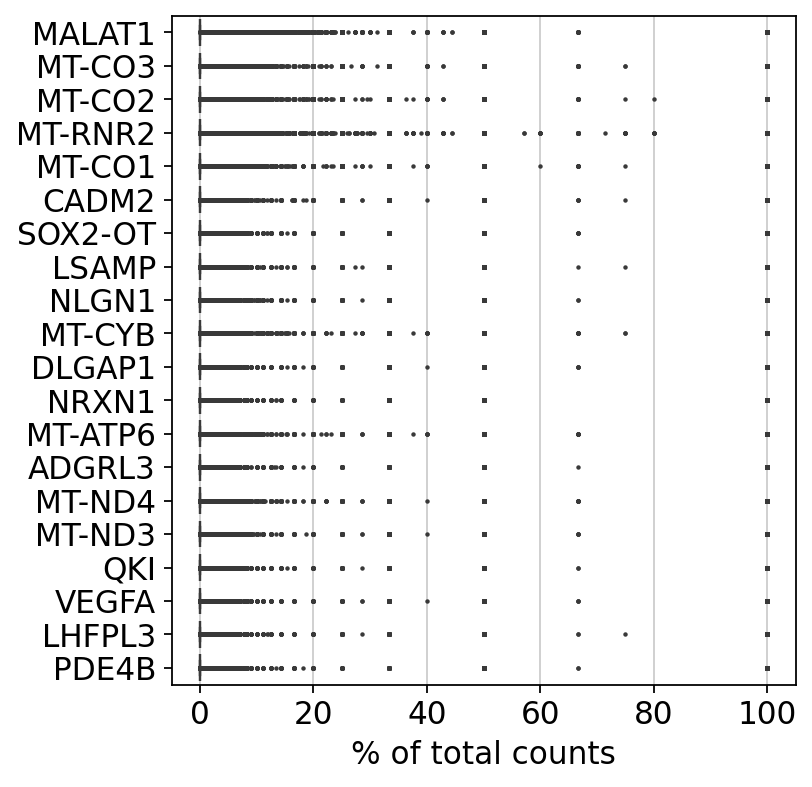

In [8]:
## Plot the highest expressed genes
sc.pl.highest_expr_genes(adata, n_top=plot_high_expression_gene_nr, save='highest_gene_expression.svg')

In [9]:
# Add external_gene_name to var_names
adata.var_names_make_unique()
adata.var['external_gene_name'] = adata.var_names
adata.var


,gene_ids,feature_types,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,external_gene_name
DDX11L1,ENSG00000223972.5,Gene Expression,0,0.000000,0.000000,100.000000,0.0,0.000000,DDX11L1
WASH7P,ENSG00000227232.5,Gene Expression,58,0.000046,0.000046,99.995421,58.0,4.077538,WASH7P
MIR6859-1,ENSG00000278267.1,Gene Expression,0,0.000000,0.000000,100.000000,0.0,0.000000,MIR6859-1
MIR1302-2HG,ENSG00000243485.5,Gene Expression,2,0.000002,0.000002,99.999842,2.0,1.098612,MIR1302-2HG
MIR1302-2,ENSG00000284332.1,Gene Expression,0,0.000000,0.000000,100.000000,0.0,0.000000,MIR1302-2
...,...,...,...,...,...,...,...,...,...
MT-ND6,ENSG00000198695.2,Gene Expression,1445,0.001487,0.001486,99.885915,1883.0,7.541152,MT-ND6
MT-TE,ENSG00000210194.1,Gene Expression,93,0.000076,0.000076,99.992658,96.0,4.574711,MT-TE
MT-CYB,ENSG00000198727.2,Gene Expression,17312,0.031709,0.031217,98.633196,40163.0,10.600726,MT-CYB
MT-TT,ENSG00000210195.2,Gene Expression,144,0.000122,0.000122,99.988631,155.0,5.049856,MT-TT


In [10]:
## filter for minimum amount of cells and genes per cell
sc.pp.filter_cells(adata, min_genes=filter_min_genes)
print('Cell count after filter for minumum ',filter_min_genes, 'features per cell: ', adata.n_obs)
sc.pp.filter_genes(adata, min_cells=filter_min_cells)
print('Feature count after filter for minumum ',filter_min_cells, 'cells per features: ', adata.n_vars)
sc.pp.filter_cells(adata, min_counts=filter_min_counts_per_cell)
print('Cell count after filter for minumum ',filter_min_counts_per_cell, 'counts per cell: ', adata.n_obs)

logfile.write(str(datetime.now())+' Cell count after filter for minumum '+ str(filter_min_genes) + ' features per cell: ' + str(adata.n_obs)+'\n')
logfile.write(str(datetime.now())+' Feature count after filter for minumum '+ str(filter_min_cells) + ' cells per features: ' + str(adata.n_vars)+'\n')
logfile.flush()

#adata.write(result_file_name+'_filtered_mg_mc.h5ad')

filtered out 1206322 cells that have less than 200 genes expressed
Cell count after filter for minumum  200 features per cell:  60282
filtered out 28509 genes that are detected in less than 3 cells
Feature count after filter for minumum  3 cells per features:  32151
filtered out 51713 cells that have less than 1000 counts
Cell count after filter for minumum  1000 counts per cell:  8569


In [11]:
## filter mitochondrial counts
# TODO: make varibale of startswith argument
# annotate the group of mitochondrial genes as 'mt'
adata.var['mt'] = adata.var_names.str.startswith('MT-')

# calculate metrics and store them in the andata format. There are many fine-tune parameters available, I implemented default here
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [12]:
adata.obs['pct_counts_mt']

AAACCCAAGATGTTCC-1    0.059277
AAACCCAAGCCACTCG-1    0.610998
AAACCCAAGCCGATAG-1    0.292010
AAACCCAAGGTGTGAC-1    0.214439
AAACCCACAGCTCATA-1    0.717703
                        ...   
TTTGTTGCAAGAAATC-1    0.160256
TTTGTTGGTCCCTGTT-1    0.217984
TTTGTTGGTCTCGACG-1    1.442938
TTTGTTGGTGCGTTTA-1    0.580552
TTTGTTGTCACGATCA-1    0.933610
Name: pct_counts_mt, Length: 8569, dtype: float32

In [13]:
# visualize some quality metrics in violin plots
# default order is width
#sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
#             jitter=0.4, multi_panel=True, save='qc_violin_plot.svg')

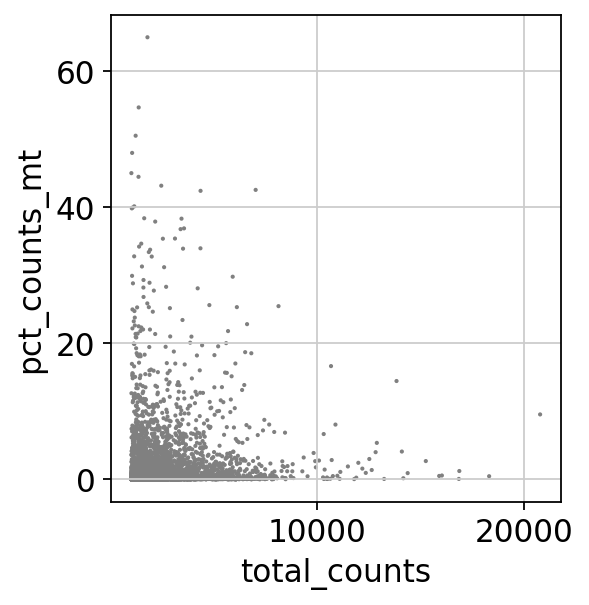

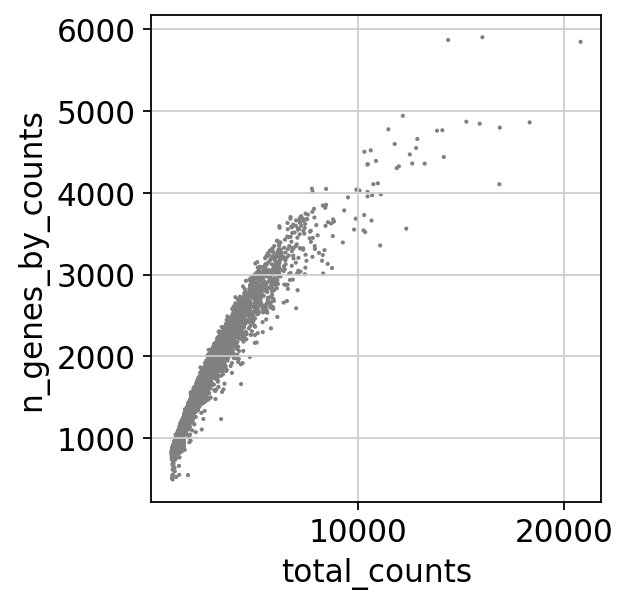

In [14]:
## further visualize mitochondrial counts with scatter plots
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt', save='scatter_total_counts_vs_pct_counts_mt.svg')
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts', save='scatter_total_counts_vs_pct_n_genes_by_counts.svg')

In [15]:
## do the filtering based on that plot or based on default thresholds
adata = adata[adata.obs.n_genes_by_counts < filter_n_genes_by_counts, :]
adata = adata[adata.obs.pct_counts_mt < filter_pct_counts_mt, :]
adata = adata[adata.obs.total_counts < filter_total_counts, :]

print('Cell count after filtering out cells with more than ',filter_n_genes_by_counts, ' expressed genes and more than', filter_pct_counts_mt, '% of mitochondrial counts and total counts < ', str(filter_total_counts)  ,':' , adata.n_obs,)
logfile.write(str(datetime.now())+' Cell count after filter out cells with less than '+ str(filter_n_genes_by_counts) + '  gene count and more than ' + str(filter_pct_counts_mt) + ' % of mitochondrial counts and total counts < '+ str(filter_total_counts)+ ': ' + str(adata.n_obs) +'\n')
logfile.flush()

## save the andata object
#adata.write(result_file_name+'_filtered_mg_mc_gc_mt_tc.h5ad')

Cell count after filtering out cells with more than  10000  expressed genes and more than 10 % of mitochondrial counts and total counts <  10000 : 8321


In [16]:
# save filtered h5ad file
filtered_file_name = result_folder + sample + '_filtered.h5ad'
adata.write(filtered_file_name)
print(f"Filtered data saved to {filtered_file_name}")

Filtered data saved to /home/borisvdm/Documents/PhD/thesis_Mirte/Wang2021/data/single_cell/C3L-03968/C3L-03968_filtered.h5ad
